# **Measuring Bias using Gensim & TF-IDF**

## Bias Axis in Word Embeddings (Two Groups of Words)

This notebook measures bias along a chosen axis in word embedding space. You will:

1. Load documents (either from a CSV, or a collection of text files)
2. Choose two groups of words on opposite ends of an axis (Group A vs Group B)
3. Use a word embedding model (like Word2Vec) to build a bias axis
4. Score each document in terms of:
    - Simple average bias
    - TF-IDF weighted bias5
5. Save the results and look at the most biased documents

In [ ]:
pip install gensim scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.6 MB/s eta 0:00:00


In [ ]:
import re, random, string, os
from pathlib import Path
import numpy as np
import pandas as pd

from gensim.models import KeyedVectors
import gensim.downloader as api
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Provide documents

Two options:
- CSV file **(easier, default)**
    - Get a dataset from [Kaggle](https://kaggle.com) or similar, where you feel there may be some bias row by row (for example, a listing of jobs with their descriptions, or news reports with their transcripts)
    - The label will be one column (ex: job title)
    - The text to be analyzed will be another (ex: job description)
- Folder of text files
    - Each file will be one document
    - The label will be the file name
    - The text will be the file contents

In [ ]:
from pathlib import Path
import pandas as pd

# ---------- LOAD DOCUMENTS (edit this!) ------------

use_csv = True  # if true: one file expected, instead of a directory

# if using a CSV:
path_csv = "500_anonymized_Reddit_users_posts_labels - 500_anonymized_Reddit_users_posts_labels.csv"
label_column = "Label"
text_column = "Post"

# if using a folder of text files:
directory_text_files = "directory_name"

# --------------------------------------------------

labels = []
docs = []

if use_csv:
    csv_path = Path(path_csv)

    # Check path BEFORE trying to read
    if not csv_path.is_file() or csv_path.suffix.lower() != ".csv":
        raise Exception(f"Path does not correspond to a valid CSV file: {path_csv}")

    df = pd.read_csv(csv_path)
    print(f"Loaded CSV with {len(df)} rows")

    # Clean up column names: strip spaces + remove BOM if present
    df.columns = (
        df.columns
        .str.strip()  # remove leading/trailing spaces
        .str.replace("\ufeff", "", regex=False)  # remove BOM if present
    )

    print("Detected columns:", df.columns.tolist())

    if label_column not in df.columns:
        raise KeyError(
            f"label_column '{label_column}' not found. "
            f"Available columns: {df.columns.tolist()}"
        )
    if text_column not in df.columns:
        raise KeyError(
            f"text_column '{text_column}' not found. "
            f"Available columns: {df.columns.tolist()}"
        )

    # Final load
    labels = df[label_column].astype(str).tolist()
    docs = df[text_column].astype(str).tolist()

# make sure everything is good to go
print(f"First label: {labels[0]}")
print(f"First text snippet: {docs[0][:200]}")


Loaded CSV with 500 rows
Detected columns: ['User', 'Post', 'Label']
First label: Supportive
First text snippet: ['Its not a viable option, and youll be leaving your wife behind. Youd Pain her beyond comprehension.It sucks worrying about money, I know that first hand. It can definitely feel hopeless, as you seem


In [ ]:
# ---------- LOAD DOCUMENTS (edit this!) ------------

use_csv = True  # if true: one file expected, instead of a directory

# if using a CSV:
path_csv = "500_anonymized_Reddit_users_posts_labels - 500_anonymized_Reddit_users_posts_labels.csv"
label_column = "Label"
text_column = "Post"

# if using a folder of text files:
directory_text_files = "directory_name"

# --------------------------------------------------

labels = []
docs = []

if use_csv:
  df = pd.read_csv(Path(path_csv))
  if not Path(path_csv).is_file() or Path(path_csv).suffix.lower() != '.csv':
    raise Exception(f"Path does not correspond to a valid CSV file: {path_csv}")
  print(f"Loaded CSV with {len(df)} rows")

  labels = df[label_column].astype(str).tolist()
  docs = df[text_column].astype(str).tolist()
else:
  text_dir = Path(directory_text_files)
  if not text_dir.exists():
    raise Exception(f"Directory {directory_text_files} does not exist")

  files = sorted(f for f in text_dir.iterdir() if f.is_file())
  if not files:
    raise Exception("No files found in directory.")

  for f in files:
    with open(f, encoding='utf-8') as ff:
      text = ff.read()
    docs.append(text)
    labels.append(f.stem) #excludes the extension

  print(f"Loaded {len(docs)} files from the directory")


# make sure everything is good to go
print(f"First label: {labels[0]}")
print(f"First text snippet: {docs[0][:200]}")

Loaded CSV with 500 rows
First label: Supportive
First text snippet: ['Its not a viable option, and youll be leaving your wife behind. Youd Pain her beyond comprehension.It sucks worrying about money, I know that first hand. It can definitely feel hopeless, as you seem


## Load a word embedding model

Choose a word2vec or gloVe model from gensim. Here are some models, but feel free to use any you like:
- `word2vec-google-news-300` (familiar!)
    - 1.6 GB -- when I tested it, it didn't exceed 10 GB of RAM, which means it *should* work on the free version of Colab (but if it doesn't, students can get free Colab Pro, so check it out!)
- `glove-wiki-gigaword-100` (small and fast)
    - 128 MB, very small and lightweigght
    - Feel free to switch to 200 or 300 for better results
- `glove-twitter-100` (great for social media datasets)
    - 387 MB, feel free to adjust to 50 or 200

In [ ]:
# ---------- LOAD MODEL (edit this!) ------------
model_name = "word2vec-google-news-300"
# ----------------------------------------------

print(f"Loading model {model_name}. This may take a bit.")
print("If this crashes, you may have exceeded Colab's RAM.\n\
Switch to Colab Pro (free for students), or use a smaller model")
model = api.load(model_name)
print(f"Finished! Embedding dimensions: {model.vector_size}")

Loading model word2vec-google-news-300. This may take a bit.
If this crashes, you may have exceeded Colab's RAM.
Switch to Colab Pro (free for students), or use a smaller model
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Finished! Embedding dimensions: 300


## Define the bias axis (Group A vs Group B)

We choose two sets of words we expect to be on opposite ends of a spectrum:

- **Group A name** -- Name of our group (examples: masculine, young, left-leaning, positive etc.)
- **Group A** -- Words associated with our group (if masculine, we could imagine: he, him, man, male, boy etc.)
- **Group B name** -- Name of our opposite group (ex: feminine-coded)
- **Group B** -- Words associated with our group (if feminine, we could imagine: she, her, woman, female, girl etc.)

The model will:

1. Average the vectors for all Group A words --> Group A vector.
2. Average the vectors for all Group B words --> Group B vector.

Later we compare each word/doc to these two vectors. The sample of words is just to get a better idea of the general area where the ends of the axis lie in an abstract sense. We want to tell whether the document leans more towards one than the other.

In [ ]:
# ---------- DEFINE AXES (edit this!) ------------

GROUP_A_NAME = "hopelessness"
GROUP_B_NAME = "support"

GROUP_A_WORDS = [
    "hopeless", "empty", "worthless", "tired", "numb",
    "alone", "hate myself", "give up", "nothing matters"
]

GROUP_B_WORDS = [
    "support", "help", "care", "love", "hope",
    "here for you", "stay strong", "you matter", "reach out"
]

# -----------------------------------------------


def words_in_vocab(words, model):
    return [w for w in words if w in model.key_to_index]

group_a_vocab = words_in_vocab(GROUP_A_WORDS, model)
group_b_vocab = words_in_vocab(GROUP_B_WORDS, model)

print(f"Group A ({GROUP_A_NAME}) words in vocab:", group_a_vocab)
print(f"Group B ({GROUP_B_NAME}) words in vocab:", group_b_vocab)

if not group_a_vocab or not group_b_vocab:
    raise ValueError("One of the groups has no words in the model vocabulary.")


def mean_vector(words, model):
    vectors = [model[w] for w in words if w in model.key_to_index]
    return np.mean(vectors, axis=0)


group_a_vec = mean_vector(group_a_vocab, model)
group_b_vec = mean_vector(group_b_vocab, model)

print("Group vectors created.")


Group A (hopelessness) words in vocab: ['hopeless', 'empty', 'worthless', 'tired', 'numb', 'alone']
Group B (support) words in vocab: ['support', 'help', 'care', 'love', 'hope']
Group vectors created.


## Tokenize

For the *simple average* bias, we will preprocess the data, and then convert each document to a list of tokens. We should also remove stopwords to prevent unfair averaging.

In [ ]:
# source: https://gist.github.com/sebleier/554280
# can edit this if it's affecting your data, but no need
stopwords = {"i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he",
             "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "should", "now"
             "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be",
             "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or",
             "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during",
             "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further",
             "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other",
             "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don"}

punct_table = str.maketrans("", "", string.punctuation)

def remove_stopwords(tokens, stopwords=stopwords):
    return [t for t in tokens if t not in stopwords]

def tokenize(text):
    text = text.lower().translate(punct_table)
    tokens = remove_stopwords(text.split())
    return tokens

tokenized_docs = [tokenize(doc) for doc in docs]
print("First 20 tokens of the first document:", tokenized_docs[0][:20])

First 20 tokens of the first document: ['viable', 'option', 'youll', 'leaving', 'wife', 'behind', 'youd', 'pain', 'beyond', 'comprehensionit', 'sucks', 'worrying', 'money', 'know', 'first', 'hand', 'definitely', 'feel', 'hopeless', 'seem']


## Word bias and document bias

We define word bias as:

`bias(word) = cos(word, GroupA) - cos(word, GroupB)`

Positive = closer to **Group A**  
Negative = closer to **Group B**

---

And there are two different ways of calculating bias:

- **Simple document bias** = average of `bias(word)` over words in the document.
- **TF–IDF document bias** = weighted average of `bias(word)` using TF–IDF weights.


In [ ]:
def cosine_similarity(u, v):
    u = np.asarray(u)
    v = np.asarray(v)
    denom = (np.linalg.norm(u) * np.linalg.norm(v))
    if denom == 0:
        return 0.0
    return float(np.dot(u, v) / denom)


def word_bias(word, model, group_a_vec, group_b_vec):
    if word not in model.key_to_index:
        return None
    w_vec = model[word]
    a_sim = cosine_similarity(w_vec, group_a_vec)
    b_sim = cosine_similarity(w_vec, group_b_vec)
    return a_sim - b_sim  # > 0 = toward Group A, < 0 = toward Group B

def document_bias_mean(tokens, model, group_a_vec, group_b_vec):
    scores = []
    for w in tokens:
        b = word_bias(w, model, group_a_vec, group_b_vec)
        if b is not None:
            scores.append(b)
    if not scores:
        return np.nan
    return float(np.mean(scores))

In [ ]:
bias_mean = [
    document_bias_mean(tokens, model, group_a_vec, group_b_vec)
    for tokens in tokenized_docs
]

print("Computed simple average bias for all documents.")

Computed simple average bias for all documents.


In [ ]:
# Build TF–IDF matrix on the raw documents
vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b"  # keep simple word tokens
)
tfidf_matrix = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

def document_bias_tfidf(doc_id, model, group_a_vec, group_b_vec,
                        tfidf_matrix, vocab):
    """
    TF–IDF weighted bias for a single document.
    """
    row = tfidf_matrix[doc_id]
    coo = row.tocoo()

    weighted_bias = 0.0
    weight_sum = 0.0

    for term_index, tfidf_value in zip(coo.col, coo.data):
        term = vocab[term_index]
        b = word_bias(term, model, group_a_vec, group_b_vec)
        if b is None:
            continue
        weighted_bias += b * tfidf_value
        weight_sum += tfidf_value

    if weight_sum == 0.0:
        return np.nan

    return float(weighted_bias / weight_sum)


bias_tfidf = [
    document_bias_tfidf(i, model, group_a_vec, group_b_vec,
                        tfidf_matrix, vocab)
    for i in range(len(docs))
]

print("Computed TF–IDF weighted bias for all documents.")

Computed TF–IDF weighted bias for all documents.


## Put everything into a table and save

We now build a `DataFrame` with:

- `label` — document label (title or file name)
- `bias_mean` — simple average bias
- `bias_tfidf` — TF–IDF weighted bias
- `text` — the original document text

Then we save it as `bias_results.csv`.

In [ ]:
results = pd.DataFrame({
    "label": labels,
    "bias_mean": bias_mean,
    "bias_tfidf": bias_tfidf,
    "text": docs,
})

results.head()


,label,bias_mean,bias_tfidf,text
0,Supportive,-0.027696,-0.017705,"['Its not a viable option, and youll be leavin..."
1,Ideation,-0.026336,-0.017510,['It can be hard to appreciate the notion that...
2,Behavior,-0.042239,-0.021895,"['Hi, so last night i was sitting on the ledge..."
3,Attempt,-0.032457,-0.018266,['I tried to kill my self once and failed badl...
4,Ideation,-0.044664,-0.027657,['Hi NEM3030. What sorts of things do you enjo...


from matplotlib import pyplot as plt
_df_24['bias_mean'].plot(kind='hist', bins=20, title='bias_mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_25['bias_tfidf'].plot(kind='hist', bins=20, title='bias_tfidf')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_26.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_27.groupby('text').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_33['text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_33, x='bias_mean', y='text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_34['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_34, x='bias_tfidf', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_35['text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_35, x='bias_tfidf', y='text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

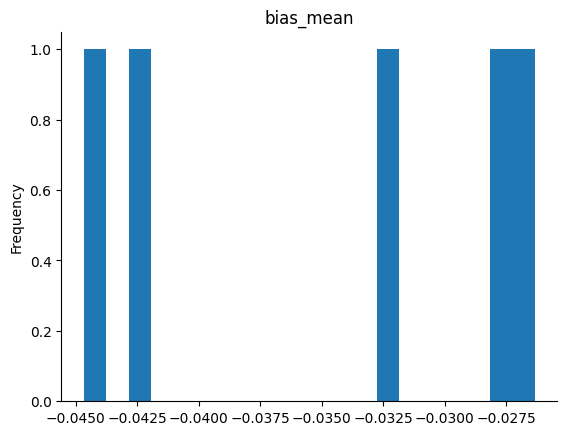

In [ ]:
from matplotlib import pyplot as plt
_df_24['bias_mean'].plot(kind='hist', bins=20, title='bias_mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

/tmp/ipython-input-267207359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(_df_20, x='bias_mean', y='label', inner='stick', palette='Dark2')


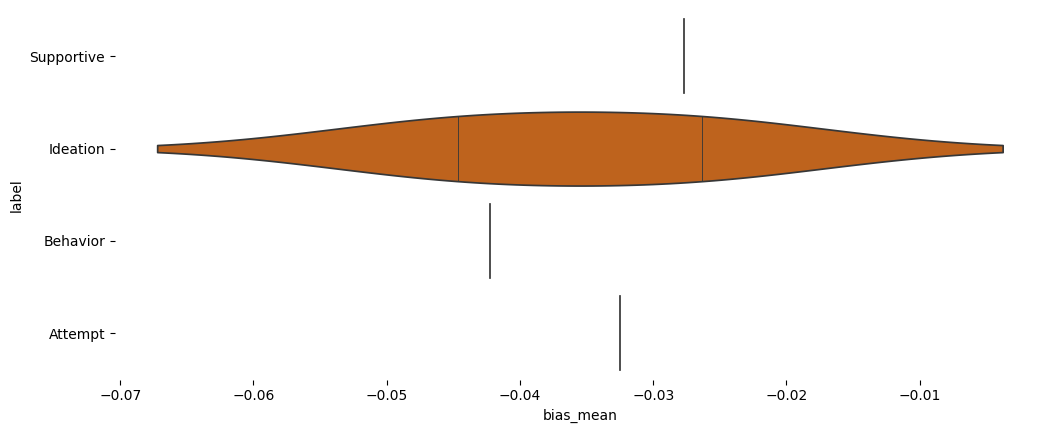

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='bias_mean', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

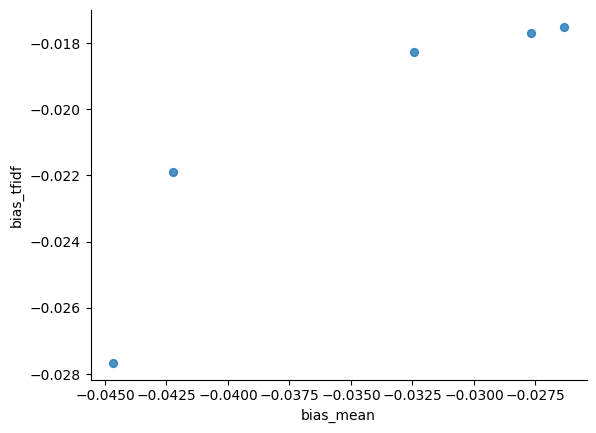

In [ ]:
from matplotlib import pyplot as plt
_df_16.plot(kind='scatter', x='bias_mean', y='bias_tfidf', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

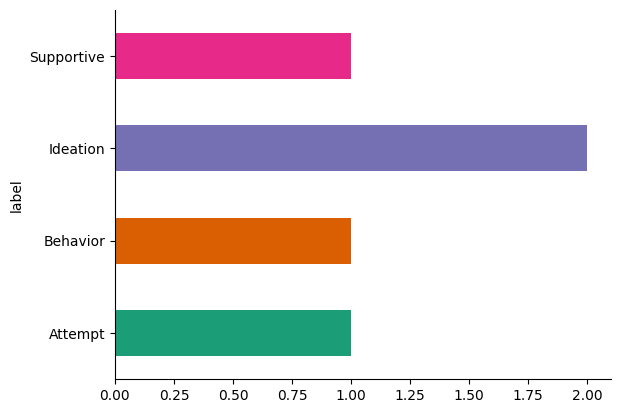

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_14.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
OUTPUT_CSV = "bias_results.csv"
results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved results to {OUTPUT_CSV}")


Saved results to bias_results.csv


In [ ]:
# ----------- HELPER FUNCTIONS to analyze your results ------------

# group: show top documents from group "A" or "B"?
# top_n: show how many top documents?
# eval_metric: are we going based off of the mean "bias_mean", or TF-IDF "bias_tfidf"?
# remove_dupes: if the same label appears several times, should we remove the duplicates?
def show_top_documents(results_df, group = "A", top_n = 10,
                       eval_metric = "bias_tfidf", remove_dupes = False):
    if group.upper() == 'A':
        ascending = False   # highest scores first
        group_name = GROUP_A_NAME
    elif group.upper() == 'B':
        ascending = True    # lowest scores first
        group_name = GROUP_B_NAME
    else:
        raise ValueError("group must be 'A' or 'B'")

    if eval_metric not in results_df.columns:
        raise ValueError(f"{eval_metric} not found in results_df.")

    # sort by bias score
    sorted_df = results_df.sort_values(eval_metric, ascending=ascending)

    if remove_dupes: sorted_df = sorted_df.drop_duplicates(subset="label", keep="first")

    # take the top N
    top = sorted_df.head(top_n).copy()

    print(f"Top {top_n} documents towards {group_name} (Group {group}):")
    for _, row in top.iterrows():
        score = row[eval_metric]
        print(f"- label: {row['label']!r}, {eval_metric} = {score:.4f}")
    print('\n')

    return top

def histogram(results):
  valid = results["bias_tfidf"].dropna()

  plt.figure()
  valid.hist(bins=30)
  plt.xlabel("bias_tfidf")
  plt.ylabel("count")
  plt.title(f"TF–IDF bias distribution: {GROUP_A_NAME} (+) vs {GROUP_B_NAME} (-)")
  plt.show()

In [ ]:
# mean
top_a_mean = show_top_documents(results, group = 'A', eval_metric = "bias_mean",
                                top_n = 10, remove_dupes = True)
top_b_mean = show_top_documents(results, group = 'B', eval_metric = "bias_mean",
                                top_n = 10, remove_dupes = True)

print("-----------------------------------------------\n")

# TF-IDF
top_a_tfidf = show_top_documents(results, group = 'A', eval_metric = "bias_tfidf",
                                 top_n = 10, remove_dupes = True)
top_b_tfidf = show_top_documents(results, group = 'B', eval_metric = "bias_tfidf",
                                 top_n = 10, remove_dupes = True)

Top 10 documents towards hopelessness (Group A):
- label: 'Behavior', bias_mean = 0.0783
- label: 'Attempt', bias_mean = 0.0241
- label: 'Supportive', bias_mean = 0.0200
- label: 'Ideation', bias_mean = 0.0133
- label: 'Indicator', bias_mean = 0.0007


Top 10 documents towards support (Group B):
- label: 'Supportive', bias_mean = -0.2581
- label: 'Ideation', bias_mean = -0.1238
- label: 'Behavior', bias_mean = -0.0900
- label: 'Indicator', bias_mean = -0.0861
- label: 'Attempt', bias_mean = -0.0659


-----------------------------------------------

Top 10 documents towards hopelessness (Group A):
- label: 'Behavior', bias_tfidf = 0.0648
- label: 'Attempt', bias_tfidf = 0.0401
- label: 'Ideation', bias_tfidf = 0.0269
- label: 'Supportive', bias_tfidf = 0.0186
- label: 'Indicator', bias_tfidf = 0.0102


Top 10 documents towards support (Group B):
- label: 'Supportive', bias_tfidf = -0.1448
- label: 'Ideation', bias_tfidf = -0.0537
- label: 'Behavior', bias_tfidf = -0.0521
- label: 'Indic

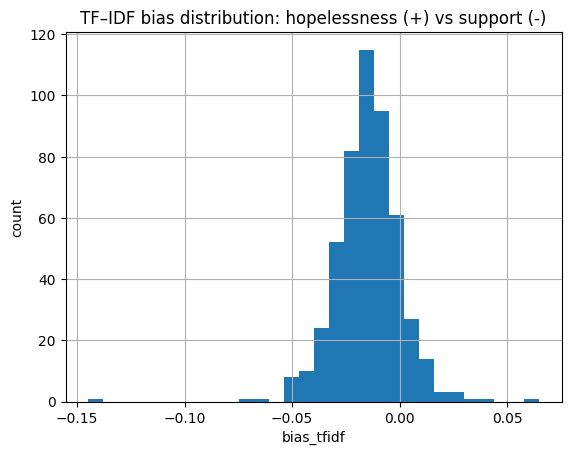

In [ ]:
histogram(results)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1) Data
X = pd.Series(docs).astype(str)
y = pd.Series(labels).astype(str)

print("Rows:", len(X))
print("Classes:", sorted(y.unique()))
print("\nClass counts:\n", y.value_counts())

# 2) Train/test split (keeps class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) TF–IDF features
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=30000
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# 4) Train classifier
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

# 5) Evaluate
y_pred = clf.predict(X_test_vec)

label_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=label_order)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=[f"true_{c}" for c in label_order],
                      columns=[f"pred_{c}" for c in label_order]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=label_order))

# 6) Top features per class (what words push the model toward each label)
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_  # (n_classes, n_features)

top_n = 15
print(f"\nTop {top_n} TF–IDF features per class:\n")
for i, class_name in enumerate(clf.classes_):
    top_idx = np.argsort(coefs[i])[-top_n:][::-1]
    print("Class:", class_name)
    for term, weight in zip(feature_names[top_idx], coefs[i][top_idx]):
        print(f"  {term:30s} {weight:.4f}")
    print()
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1) Data
X = pd.Series(docs).astype(str)
y = pd.Series(labels).astype(str)

print("Rows:", len(X))
print("Classes:", sorted(y.unique()))
print("\nClass counts:\n", y.value_counts())

# 2) Train/test split (keeps class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) TF–IDF features
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=30000
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# 4) Train classifier
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_vec, y_train)

# 5) Evaluate
y_pred = clf.predict(X_test_vec)

label_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=label_order)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=[f"true_{c}" for c in label_order],
                      columns=[f"pred_{c}" for c in label_order]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=label_order))

# 6) Top features per class (what words push the model toward each label)
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_  # (n_classes, n_features)

top_n = 15
print(f"\nTop {top_n} TF–IDF features per class:\n")
for i, class_name in enumerate(clf.classes_):
    top_idx = np.argsort(coefs[i])[-top_n:][::-1]
    print("Class:", class_name)
    for term, weight in zip(feature_names[top_idx], coefs[i][top_idx]):
        print(f"  {term:30s} {weight:.4f}")
    print()


Rows: 500
Classes: ['Attempt', 'Behavior', 'Ideation', 'Indicator', 'Supportive']

Class counts:
 Ideation      171
Supportive    108
Indicator      99
Behavior       77
Attempt        45
Name: count, dtype: int64

Confusion Matrix (rows=true, cols=pred):
                 pred_Attempt  pred_Behavior  pred_Ideation  pred_Indicator  \
true_Attempt                0              3              3               2   
true_Behavior               1              5              6               1   
true_Ideation               0              6             11               9   
true_Indicator              0              3              7               4   
true_Supportive             0              0              5               8   

                 pred_Supportive  
true_Attempt                   1  
true_Behavior                  2  
true_Ideation                  8  
true_Indicator                 6  
true_Supportive                9  

Classification Report:
              precision    recall  

The creation of some functions in this notebook received assistance from ChatGPT (OpenAI)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# =======================
# 1) Load data
# =======================
use_csv = True  # if true: one file expected, instead of a directory

# if using a CSV:
path_csv = "500_anonymized_Reddit_users_posts_labels - 500_anonymized_Reddit_users_posts_labels.csv"
label_column = "Label"
text_column = "Post"

# if using a folder of text files:
directory_text_files = "directory_name"

# =======================
# 2) TF–IDF vectorization
# =======================
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

# =======================
# 3) Train Logistic Regression
# =======================
clf = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    multi_class="ovr"
)

clf.fit(X_train_tfidf, y_train)

# =======================
# 4) Remove filler words
# =======================
FILLER_WORDS = {
    "im", "ive", "dont", "youre", "youll",
    "like", "just", "id", "dont know", "ive lost"
}

def is_informative(term):
    return (
        term not in FILLER_WORDS
        and len(term) > 3
    )

# =======================
# 5) Extract poster-ready TF–IDF features
# =======================
feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_
coefs = clf.coef_

TOP_N = 4  # ideal for poster

print("\nPoster-ready TF–IDF features per class:\n")

for i, c in enumerate(classes):
    sorted_idx = np.argsort(coefs[i])[::-1]

    filtered_terms = [
        feature_names[j]
        for j in sorted_idx
        if is_informative(feature_names[j])
    ]

    top_terms = filtered_terms[:TOP_N]

    print(f"{c}: {', '.join(top_terms)}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Poster-ready TF–IDF features per class:

Attempt: attempt, somebody, suicide attempt, failed
Behavior: cutting, hospital, felt, kill im
Ideation: thank, depression, mental depression, mental
Indicator: behavior, hyperactive, hyperactive behavior, haha
Supportive: think, sounds, therapist help, chocolate
